# <center> <img src="../img/ITESOLogo.png" alt="ITESO" width="480" height="130"> </center>
# <center> **Departamento de Electrónica, Sistemas e Informática** </center>
---
## <center> **Big Data** </center>
---
### <center> **Spring 2026** </center>
---
### <center> **Lab 5** </center>
---
**Profesor**: Pablo Camarillo Ramirez

**Students**: Juan Pablo Perez Lopez
              Alejandro Rodriguez Veloquio


In [1]:
from spark_utils import SparkUtils

su = SparkUtils(
    "Lab 5",
    "spark://spark-master:7077",
    spark_jars="/opt/spark/work-dir/notebooks/jars/postgresql-42.7.8.jar"
)
su.spark



26/03/12 15:03:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [5]:
import pyspark.sql.functions as F
movies_columns = [("MovieID", "int"),
                  ("Title", "string"),
                  ("Genre", "string"),
                  ("ReleaseYear", "int"),
                  ("ReleaseDate_Str", "string"),
                  ("Country", "string"),
                  ("BudgetUSD", "float"),
                  ("US_BoxOfficeUSD", "float"),
                  ("Global_BoxOfficeUSD", "float"),
                  ("Opening_Day_SalesUSD", "float"),
                  ("One_Week_SalesUSD", "float"),
                  ("IMDbRating", "float"),
                  ("RottenTomatoesScore", "float"),
                  ("NumVotesIMDb", "int"),
                  ("NumVotesRT", "int"),
                  ("Director", "string"),
                  ("LeadActor", "string")]

movies_schema = SparkUtils.generate_schema(movies_columns)

movies_date_str_df = (su.spark.read 
                .option("header", "true")
                .schema(movies_schema)
                .csv("/opt/spark/work-dir/data/movies/"))

movies_df = movies_date_str_df.withColumn("ReleaseDate", F.to_date("ReleaseDate_Str", "dd-MM-yyyy")).drop("ReleaseDate_Str")
#movies_df = movies_df.groupBy("Genre").count().orderBy(F.col("count"), ascending=False)
movies_df.show()

+-------+--------------------+-----------+-----------+-------+-----------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+------------------+------------------+-----------+
|MovieID|               Title|      Genre|ReleaseYear|Country|  BudgetUSD|US_BoxOfficeUSD|Global_BoxOfficeUSD|Opening_Day_SalesUSD|One_Week_SalesUSD|IMDbRating|RottenTomatoesScore|NumVotesIMDb|NumVotesRT|          Director|         LeadActor|ReleaseDate|
+-------+--------------------+-----------+-----------+-------+-----------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+------------------+------------------+-----------+
|      1|Might toward capital|     Comedy|       2003|  China|  6577428.0|      6613686.0|        1.5472036E7|           1778530.9|        3034053.2|       6.2|               58.0|        7865|     10596|    Kristina Moore|   Brian Mcc

In [6]:
movies_df.printSchema()

root
 |-- MovieID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Genre: string (nullable = true)
 |-- ReleaseYear: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- BudgetUSD: float (nullable = true)
 |-- US_BoxOfficeUSD: float (nullable = true)
 |-- Global_BoxOfficeUSD: float (nullable = true)
 |-- Opening_Day_SalesUSD: float (nullable = true)
 |-- One_Week_SalesUSD: float (nullable = true)
 |-- IMDbRating: float (nullable = true)
 |-- RottenTomatoesScore: float (nullable = true)
 |-- NumVotesIMDb: integer (nullable = true)
 |-- NumVotesRT: integer (nullable = true)
 |-- Director: string (nullable = true)
 |-- LeadActor: string (nullable = true)
 |-- ReleaseDate: date (nullable = true)



In [ ]:

sdf = (movies_df
       .groupBy("ReleaseYear")
       .agg(F.avg("Global_BoxOfficeUSD").alias("avg_global"))
       .orderBy("ReleaseYear"))

pdf = sdf.toPandas()



'\nplt.figure()\nplt.plot(pdf["ReleaseYear"], pdf["avg_global"])\nplt.title("Line: Avg Global Box Office per Year")\nplt.xlabel("ReleaseYear")\nplt.ylabel("Avg Global Box Office (USD)")\nplt.show()\n'

In [8]:
jdbc_url = "jdbc:postgresql://postgres-iteso:5432/postgres"
table_name = "movies_transformed"

sdf.write \
    .format("jdbc") \
    .option("url", jdbc_url) \
    .option("dbtable", table_name) \
    .option("user", "postgres") \
    .option("password", "Admin@1234") \
    .option("driver", "org.postgresql.Driver") \
    .mode("overwrite") \
    .save()

print("DataFrame successfully written into a PosgreSQL DB !")

DataFrame successfully written into a PosgreSQL DB !


In [9]:
jdbc_url = "jdbc:postgresql://postgres-iteso:5432/postgres"
db_properties = {
 "user": "postgres",
 "password": "Admin@1234",
 "driver": "org.postgresql.Driver"
 }
df = (su.spark.read
 .jdbc(url=jdbc_url, table=table_name, properties=db_properties))
df.printSchema()
df.show(truncate=False)


root
 |-- ReleaseYear: integer (nullable = true)
 |-- avg_global: double (nullable = true)

+-----------+--------------------+
|ReleaseYear|avg_global          |
+-----------+--------------------+
|1950       |2.961883212781083E7 |
|1951       |2.772574984145977E7 |
|1952       |2.632153237738334E7 |
|1953       |2.665446078383404E7 |
|1954       |3.0222079809324495E7|
|1955       |2.75424025906906E7  |
|1956       |2.862306672741911E7 |
|1957       |2.659146085695577E7 |
|1958       |2.8166061454816226E7|
|1959       |2.745541728559338E7 |
|1960       |2.7643066769097548E7|
|1961       |2.7279919113819946E7|
|1962       |2.5829309242541037E7|
|1963       |2.6444943127706323E7|
|1964       |2.6777090161831427E7|
|1965       |2.7988671217590064E7|
|1966       |2.7347738264353357E7|
|1967       |2.7347476325682938E7|
|1968       |2.863369514011324E7 |
|1969       |2.690379729399118E7 |
+-----------+--------------------+
only showing top 20 rows


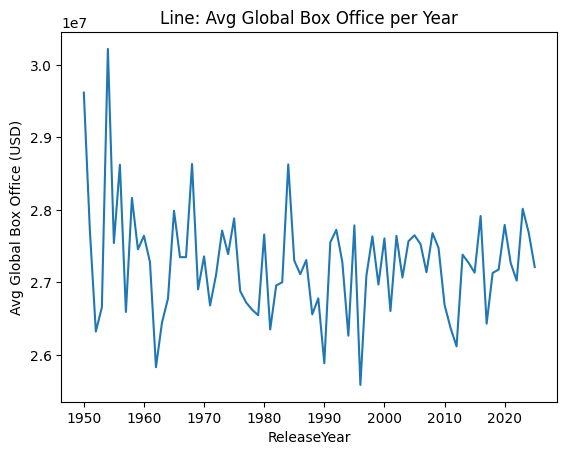

In [10]:
import matplotlib.pyplot as plt
pdf_from_db = df.toPandas()

plt.figure()
plt.plot(pdf_from_db["ReleaseYear"], pdf_from_db["avg_global"])
plt.title("Line: Avg Global Box Office per Year")
plt.xlabel("ReleaseYear")
plt.ylabel("Avg Global Box Office (USD)")
plt.show()
